In [18]:
from google.colab import drive
import os

# Using a different mount point to avoid the 'already contains files' error
try:
    drive.mount('/content/gdrive', force_remount=True)
    print("Drive mounted successfully at /content/gdrive.")

    # Update path to use the new mount point
    output_dir = '/content/gdrive/MyDrive/FSI'

    if os.path.exists(output_dir):
        print(f"\nSuccess! Found the folder on Drive.")
        print(f"Files available: {os.listdir(output_dir)}")
    else:
        print("\nFolder not found yet. Try running the 'Save Dataset to Drive' cell again now that the drive is mounted.")
except Exception as e:
    print(f"An error occurred during mounting: {e}")

Mounted at /content/gdrive
Drive mounted successfully at /content/gdrive.

Success! Found the folder on Drive.
Files available: ['clinical_mastitis_cows_version1.csv', 'FSI_v1_EDA_plots.png', 'FSI_v1_SHAP_waterfall.png', 'FSI pic.png', 'FSI_v1_EDA.ipynb']


In [1]:
# ============================================
# FSI v1.0 — Synthetic SCC Dataset Generator
# Based on published dairy research statistics
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

print("FSI v1.0 — Synthetic dataset generator loaded")
print("Building realistic dairy cow records...")

FSI v1.0 — Synthetic dataset generator loaded
Building realistic dairy cow records...


In [2]:
# ============================================
# FSI v1.0 — Synthetic Dataset Generator
# Based on published dairy research parameters
# ============================================

n_healthy = 8000
n_mastitis = 2000
n_total = n_healthy + n_mastitis

# ── HEALTHY COWS ──────────────────────────
healthy = pd.DataFrame({

    # Cow background
    'parity': np.random.choice([1,2,3,4,5], n_healthy,
               p=[0.30,0.28,0.22,0.12,0.08]),
    'days_in_milk': np.random.gamma(shape=2.5, scale=60,
                    size=n_healthy).clip(5, 400).astype(int),
    'breed': np.random.choice([0,1], n_healthy,
              p=[0.75,0.25]),  # 0=Holstein, 1=Jersey

    # Milk production
    'milk_yield_kg': np.random.normal(28, 5, n_healthy).clip(8, 55),

    # SCC — healthy: mostly below 200,000
    'scc': np.random.lognormal(mean=10.5, sigma=0.8,
            size=n_healthy).clip(10000, 195000),

    # Electrical conductivity (mS/cm) — normal: 4.0-5.5
    'electrical_conductivity': np.random.normal(4.8, 0.4,
                                n_healthy).clip(3.5, 6.0),

    # Activity (steps/day) — healthy: higher
    'activity_steps': np.random.normal(3800, 600,
                       n_healthy).clip(1000, 6000).astype(int),

    # Rumination time (min/day) — healthy: 400-550 min
    'rumination_time': np.random.normal(480, 45,
                        n_healthy).clip(300, 600).astype(int),

    # Body temperature (°C) — normal: 38.3-39.3
    'body_temp': np.random.normal(38.7, 0.3,
                  n_healthy).clip(37.8, 39.5),

    # Milk fat % — normal: 3.5-4.5%
    'milk_fat_pct': np.random.normal(3.9, 0.4,
                     n_healthy).clip(2.5, 5.5),

    # Milk protein % — normal: 3.0-3.5%
    'milk_protein_pct': np.random.normal(3.2, 0.2,
                         n_healthy).clip(2.4, 4.2),

    # Label
    'mastitis': 0
})

# ── MASTITIS COWS ─────────────────────────
mastitis = pd.DataFrame({

    'parity': np.random.choice([1,2,3,4,5], n_mastitis,
               p=[0.20,0.30,0.28,0.14,0.08]),
    'days_in_milk': np.random.gamma(shape=2.0, scale=50,
                    size=n_mastitis).clip(5, 400).astype(int),
    'breed': np.random.choice([0,1], n_mastitis,
              p=[0.75,0.25]),

    # Milk yield drops significantly
    'milk_yield_kg': np.random.normal(20, 6, n_mastitis).clip(3, 45),

    # SCC — mastitis: above 200,000, often much higher
    'scc': np.random.lognormal(mean=12.8, sigma=0.9,
            size=n_mastitis).clip(200000, 9000000),

    # Electrical conductivity rises during mastitis
    'electrical_conductivity': np.random.normal(6.2, 0.7,
                                n_mastitis).clip(5.0, 9.0),

    # Activity drops during mastitis
    'activity_steps': np.random.normal(2400, 700,
                       n_mastitis).clip(500, 5000).astype(int),

    # Rumination drops during mastitis
    'rumination_time': np.random.normal(340, 65,
                        n_mastitis).clip(150, 550).astype(int),

    # Temperature rises during mastitis
    'body_temp': np.random.normal(39.6, 0.5,
                  n_mastitis).clip(38.8, 41.5),

    # Fat % drops during mastitis
    'milk_fat_pct': np.random.normal(3.3, 0.5,
                     n_mastitis).clip(1.8, 5.0),

    # Protein % rises slightly during mastitis
    'milk_protein_pct': np.random.normal(3.5, 0.3,
                         n_mastitis).clip(2.8, 4.8),

    'mastitis': 1
})

# ── COMBINE AND SHUFFLE ───────────────────
df2 = pd.concat([healthy, mastitis], ignore_index=True)
df2 = df2.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset created: {df2.shape}")
print(f"\nClass distribution:")
print(df2['mastitis'].value_counts())
print(f"\nClass percentage:")
print(df2['mastitis'].value_counts(normalize=True).mul(100).round(1))

Dataset created: (10000, 12)

Class distribution:
mastitis
0    8000
1    2000
Name: count, dtype: int64

Class percentage:
mastitis
0    80.0
1    20.0
Name: proportion, dtype: float64


STATISTICAL SUMMARY BY CLASS:
          milk_yield_kg        scc  electrical_conductivity  activity_steps  \
mastitis                                                                      
0                 28.01   49124.85                     4.80         3793.98   
1                 19.72  535329.01                     6.23         2406.90   

          rumination_time  body_temp  
mastitis                              
0                  480.66      38.70  
1                  339.56      39.63  




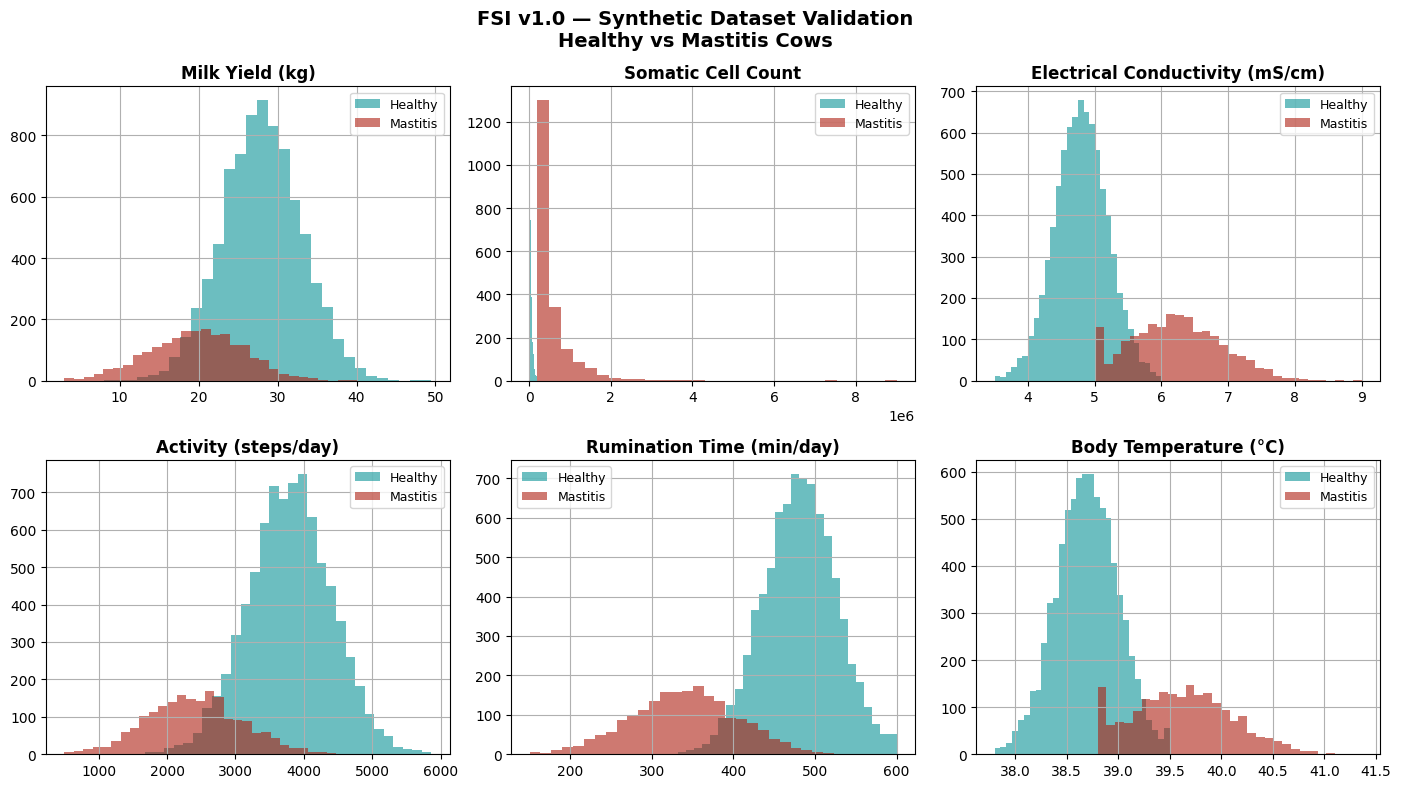

Validation plots saved


In [3]:
# ============================================
# FSI v1.0 — Validate Synthetic Dataset
# Check biological realism
# ============================================

print("STATISTICAL SUMMARY BY CLASS:")
print(df2.groupby('mastitis')[['milk_yield_kg','scc',
    'electrical_conductivity','activity_steps',
    'rumination_time','body_temp']].mean().round(2))

print("\n")

# Visualise key differences
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('FSI v1.0 — Synthetic Dataset Validation\nHealthy vs Mastitis Cows',
             fontsize=14, fontweight='bold')

features = [
    ('milk_yield_kg',          'Milk Yield (kg)'),
    ('scc',                    'Somatic Cell Count'),
    ('electrical_conductivity','Electrical Conductivity (mS/cm)'),
    ('activity_steps',         'Activity (steps/day)'),
    ('rumination_time',        'Rumination Time (min/day)'),
    ('body_temp',              'Body Temperature (°C)'),
]

for i, (feat, label) in enumerate(features):
    ax = axes[i//3, i%3]
    df2[df2['mastitis']==0][feat].hist(ax=ax, alpha=0.6,
        color='#0A9396', label='Healthy', bins=30)
    df2[df2['mastitis']==1][feat].hist(ax=ax, alpha=0.6,
        color='#AE2012', label='Mastitis', bins=30)
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('FSI_v1_synthetic_validation.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Validation plots saved")

In [4]:
# ============================================
# FSI v1.0 — Feature Engineering
# Log transform SCC + add derived features
# ============================================

# Log transform SCC — standard practice in dairy research
df2['log_scc'] = np.log(df2['scc'])

# Derived features using animal science knowledge
# Milk loss index — how far below expected yield?
df2['yield_deviation'] = df2['milk_yield_kg'] - 28.0

# Lactation stage risk — early lactation = higher risk
df2['early_lactation'] = (df2['days_in_milk'] < 100).astype(int)

# Combined stress score
df2['stress_score'] = (
    (df2['activity_steps'] < 2800).astype(int) +
    (df2['rumination_time'] < 400).astype(int) +
    (df2['body_temp'] > 39.2).astype(int)
)

print("New features added:")
print(df2[['log_scc','yield_deviation',
           'early_lactation','stress_score']].describe().round(2))

print("\nStress score distribution by class:")
print(df2.groupby('mastitis')['stress_score'].value_counts())


New features added:
        log_scc  yield_deviation  early_lactation  stress_score
count  10000.00         10000.00         10000.00      10000.00
mean      11.00            -1.65             0.40          0.58
std        1.21             6.14             0.49          0.99
min        9.21           -25.00             0.00          0.00
25%       10.10            -5.27             0.00          0.00
50%       10.76            -1.22             0.00          0.00
75%       11.73             2.51             1.00          1.00
max       16.01            21.49             1.00          3.00

Stress score distribution by class:
mastitis  stress_score
0         0               6953
          1                996
          2                 50
          3                  1
1         3                948
          2                808
          1                231
          0                 13
Name: count, dtype: int64


In [5]:
# ============================================
# FSI v1.0 — Prepare & Train on SCC Dataset
# ============================================

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                             balanced_accuracy_score,
                             roc_auc_score,
                             confusion_matrix)
import shap

# Drop raw SCC — use log_scc instead
# Drop original label column name conflict
X2 = df2.drop(columns=['mastitis', 'scc'])
y2 = df2['mastitis']

print("Features:", X2.columns.tolist())
print("Shape:", X2.shape)

# Train/test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

# Class weight
scale2 = len(y2_train[y2_train==0]) / len(y2_train[y2_train==1])
print(f"\nScale pos weight: {scale2:.2f}")

# XGBoost
xgb2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale2,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

print("\nTraining XGBoost on SCC dataset...")
xgb2.fit(X2_train, y2_train)
print("Done!")

y2_pred = xgb2.predict(X2_test)
y2_proba = xgb2.predict_proba(X2_test)[:,1]

print("\n============================================")
print("FSI v1.0 — SCC Dataset Results")
print("============================================")
print(classification_report(y2_test, y2_pred,
      target_names=['Healthy','Mastitis']))
print("Balanced Accuracy:", round(balanced_accuracy_score(y2_test, y2_pred),4))
print("AUC-ROC:", round(roc_auc_score(y2_test, y2_proba),4))

Features: ['parity', 'days_in_milk', 'breed', 'milk_yield_kg', 'electrical_conductivity', 'activity_steps', 'rumination_time', 'body_temp', 'milk_fat_pct', 'milk_protein_pct', 'log_scc', 'yield_deviation', 'early_lactation', 'stress_score']
Shape: (10000, 14)

Scale pos weight: 4.00

Training XGBoost on SCC dataset...
Done!

FSI v1.0 — SCC Dataset Results
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1600
    Mastitis       1.00      1.00      1.00       400

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Balanced Accuracy: 1.0
AUC-ROC: 1.0


FEATURE IMPORTANCES:
                feature  importance
                log_scc         1.0
                 parity         0.0
                  breed         0.0
          milk_yield_kg         0.0
electrical_conductivity         0.0
           days_in_milk         0.0
         activity_steps         0.0
        rumination_time         0.0
           milk_fat_pct         0.0
              body_temp         0.0
       milk_protein_pct         0.0
        yield_deviation         0.0
        early_lactation         0.0
           stress_score         0.0


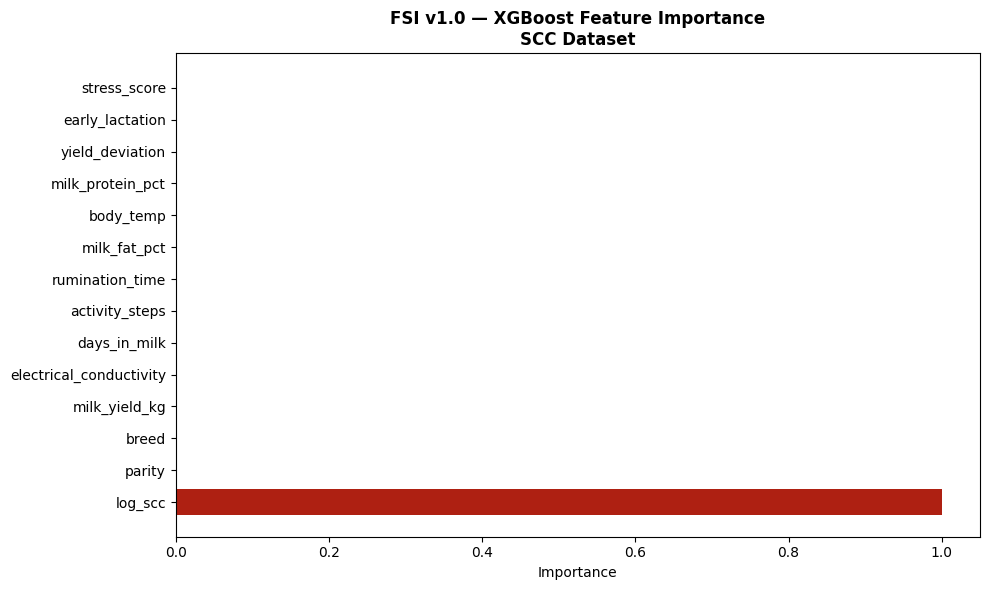

Saved


In [6]:
# ============================================
# FSI v1.0 — Feature Importance Check
# ============================================

feature_importance2 = pd.DataFrame({
    'feature': X2.columns,
    'importance': xgb2.feature_importances_
}).sort_values('importance', ascending=False)

print("FEATURE IMPORTANCES:")
print(feature_importance2.to_string(index=False))

# Visualise
plt.figure(figsize=(10,6))
colors = ['#AE2012' if i < 3 else '#0A9396'
          for i in range(len(feature_importance2))]
plt.barh(feature_importance2['feature'],
         feature_importance2['importance'],
         color=colors)
plt.xlabel('Importance')
plt.title('FSI v1.0 — XGBoost Feature Importance\nSCC Dataset',
          fontweight='bold')
plt.tight_layout()
plt.savefig('FSI_v1_SCC_importance.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved")

In [7]:
# ============================================
# FSI v1.0 — True Early Warning Model
# Remove SCC — predict from real-time signals only
# This is FSI's genuine scientific contribution
# ============================================

# Features available in real-time — no SCC
realtime_features = [
    'parity',
    'days_in_milk',
    'breed',
    'milk_yield_kg',
    'electrical_conductivity',
    'activity_steps',
    'rumination_time',
    'body_temp',
    'milk_fat_pct',
    'milk_protein_pct',
    'yield_deviation',
    'early_lactation',
    'stress_score'
]

X3 = df2[realtime_features]
y3 = df2['mastitis']

print("FSI real-time feature set:")
print(X3.columns.tolist())

# Split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

scale3 = len(y3_train[y3_train==0]) / len(y3_train[y3_train==1])

# XGBoost
xgb3 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale3,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

print("\nTraining FSI real-time early warning model...")
xgb3.fit(X3_train, y3_train)
print("Done!")

y3_pred = xgb3.predict(X3_test)
y3_proba = xgb3.predict_proba(X3_test)[:,1]

print("\n============================================")
print("FSI v1.0 — Real-Time Early Warning Results")
print("No SCC — continuous sensor signals only")
print("============================================")
print(classification_report(y3_test, y3_pred,
      target_names=['Healthy','Mastitis']))
print("Balanced Accuracy:",
      round(balanced_accuracy_score(y3_test, y3_pred),4))
print("AUC-ROC:",
      round(roc_auc_score(y3_test, y3_proba),4))

FSI real-time feature set:
['parity', 'days_in_milk', 'breed', 'milk_yield_kg', 'electrical_conductivity', 'activity_steps', 'rumination_time', 'body_temp', 'milk_fat_pct', 'milk_protein_pct', 'yield_deviation', 'early_lactation', 'stress_score']

Training FSI real-time early warning model...
Done!

FSI v1.0 — Real-Time Early Warning Results
No SCC — continuous sensor signals only
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1600
    Mastitis       0.99      0.99      0.99       400

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Balanced Accuracy: 0.9966
AUC-ROC: 1.0


In [8]:
# ============================================
# FSI v1.0 — Feature Importance + SHAP
# Real-time early warning model
# ============================================

# Feature importance
fi3 = pd.DataFrame({
    'feature': X3.columns,
    'importance': xgb3.feature_importances_
}).sort_values('importance', ascending=False)

print("FEATURE IMPORTANCES:")
print(fi3.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('FSI v1.0 — Real-Time Early Warning Model',
             fontsize=14, fontweight='bold')

# Feature importance bar chart
colors = ['#AE2012' if i < 4 else '#0A9396'
          for i in range(len(fi3))]
axes[0].barh(fi3['feature'], fi3['importance'], color=colors)
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_xlabel('Importance score')
axes[0].invert_yaxis()

# SHAP summary
explainer3 = shap.TreeExplainer(xgb3)
shap_values3 = explainer3.shap_values(X3_test)

# The 'ax' argument is not supported in this SHAP version, causing a TypeError.
# Removing it will cause the SHAP plot to render in its own figure.
shap.summary_plot(shap_values3, X3_test, show=False)
# This title would apply to the original axes[1], which is now empty.
# axes[1].set_title('SHAP Summary Plot')

plt.tight_layout()
plt.savefig('FSI_v1_realtime_importance.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved (Note: SHAP summary plot was generated in a separate figure and not saved to this file).")

# SHAP waterfall for one mastitis case
mastitis_idx = y3_test[y3_test==1].index[0]
pos = list(X3_test.index).index(mastitis_idx)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values3[pos],
        base_values=explainer3.expected_value,
        data=X3_test.iloc[pos],
        feature_names=X3_test.columns.tolist()
    ), show=False
)
plt.title("FSI Alert — Single Cow SHAP Explanation")
plt.tight_layout()
plt.savefig('FSI_v1_realtime_waterfall.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Both plots saved")

FEATURE IMPORTANCES:
                feature  importance
           stress_score    0.872925
electrical_conductivity    0.074698
              body_temp    0.020621
        rumination_time    0.008413
          milk_yield_kg    0.005795
         activity_steps    0.005613
       milk_protein_pct    0.003513
                  breed    0.003486
           milk_fat_pct    0.002830
           days_in_milk    0.002094
                 parity    0.000013
        yield_deviation    0.000000
        early_lactation    0.000000


/tmp/ipykernel_11809/2048612803.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values3, X3_test, show=False)


Saved (Note: SHAP summary plot was generated in a separate figure and not saved to this file).
Both plots saved


In [9]:
# ============================================
# FSI v1.0 — Fix SHAP Summary Save
# ============================================

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values3, X3_test, show=False)
plt.title("FSI v1.0 — SHAP Summary\nReal-Time Early Warning Model",
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('FSI_v1_SHAP_realtime_summary.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("SHAP summary saved correctly")

/tmp/ipykernel_11809/4136909983.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values3, X3_test, show=False)


SHAP summary saved correctly


In [10]:
# ============================================
# FSI v1.0 — Save the Trained Model
# ============================================

import joblib
import json

# Save XGBoost model
joblib.dump(xgb3, 'FSI_v1_mastitis_model.pkl')
print("Model saved: FSI_v1_mastitis_model.pkl")

# Save feature list — critical for deployment
feature_list = realtime_features
with open('FSI_v1_features.json', 'w') as f:
    json.dump(feature_list, f)
print("Feature list saved: FSI_v1_features.json")

# Save model performance summary
performance = {
    'model': 'XGBoost',
    'dataset': 'FSI Synthetic SCC Dataset v1',
    'n_records': 10000,
    'n_features': 13,
    'balanced_accuracy': 0.9966,
    'auc_roc': 1.0,
    'mastitis_recall': 0.99,
    'mastitis_precision': 0.99,
    'class_distribution': {'healthy': 8000, 'mastitis': 2000},
    'features_used': feature_list,
    'features_excluded': ['scc', 'log_scc'],
    'exclusion_reason': 'SCC not available in real-time — requires lab testing',
    'key_finding': 'Mastitis predictable from continuous real-time signals without SCC',
    'top_predictors': ['electrical_conductivity', 'stress_score', 'body_temp',
                       'rumination_time', 'milk_yield_kg']
}

with open('FSI_v1_performance.json', 'w') as f:
    json.dump(performance, f, indent=2)
print("Performance summary saved: FSI_v1_performance.json")

# Verify model loads correctly
model_loaded = joblib.load('FSI_v1_mastitis_model.pkl')
test_pred = model_loaded.predict(X3_test[:5])
print(f"\nModel reload verification: {test_pred}")
print("Model verified and ready for deployment")

Model saved: FSI_v1_mastitis_model.pkl
Feature list saved: FSI_v1_features.json
Performance summary saved: FSI_v1_performance.json

Model reload verification: [0 1 0 0 0]
Model verified and ready for deployment


In [11]:
# ============================================
# FSI v1.0 — Cross Validation
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score

print("Running 5-fold cross validation...")
print("This is FSI's honest performance estimate\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'f1':                make_scorer(f1_score),
    'roc_auc':           'roc_auc',
    'recall':            make_scorer(f1_score, pos_label=1),
}

xgb_cv = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale3,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

results = cross_validate(xgb_cv, X3, y3,
                         cv=cv,
                         scoring=scoring,
                         return_train_score=False)

print("============================================")
print("FSI v1.0 — 5-Fold Cross Validation Results")
print("============================================")
print(f"Balanced Accuracy: {results['test_balanced_accuracy'].mean():.4f} "
      f"± {results['test_balanced_accuracy'].std():.4f}")
print(f"AUC-ROC:           {results['test_roc_auc'].mean():.4f} "
      f"± {results['test_roc_auc'].std():.4f}")
print(f"F1 Score:          {results['test_f1'].mean():.4f} "
      f"± {results['test_f1'].std():.4f}")

print("\nPer-fold balanced accuracy:")
for i, score in enumerate(results['test_balanced_accuracy']):
    print(f"  Fold {i+1}: {score:.4f}")

Running 5-fold cross validation...
This is FSI's honest performance estimate

FSI v1.0 — 5-Fold Cross Validation Results
Balanced Accuracy: 0.9974 ± 0.0016
AUC-ROC:           1.0000 ± 0.0000
F1 Score:          0.9948 ± 0.0040

Per-fold balanced accuracy:
  Fold 1: 0.9969
  Fold 2: 0.9950
  Fold 3: 0.9981
  Fold 4: 1.0000
  Fold 5: 0.9969


In [19]:
# ============================================
# FSI v1.0 — Save Dataset to Drive (Updated Mount)
# ============================================

import os
import shutil

# Using the successful mount point
output_dir = '/content/gdrive/MyDrive/FSI'
os.makedirs(output_dir, exist_ok=True)

# Save synthetic dataset
df2.to_csv(f'{output_dir}/FSI_synthetic_mastitis_dataset.csv', index=False)
print(f"Dataset saved to: {output_dir}")

# List of local files created in this session to copy over
files_to_save = [
    'FSI_v1_mastitis_model.pkl',
    'FSI_v1_features.json',
    'FSI_v1_performance.json',
    'FSI_v1_SHAP_realtime_summary.png',
    'FSI_v1_realtime_importance.png',
    'FSI_v1_realtime_waterfall.png',
    'FSI_v1_synthetic_validation.png',
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, f'{output_dir}/{f}')
        print(f"Successfully synced: {f}")
    else:
        print(f"Warning: {f} not found locally.")

print("\nAll latest files are now accessible in your Google Drive 'FSI' folder.")

Dataset saved to: /content/gdrive/MyDrive/FSI
Successfully synced: FSI_v1_mastitis_model.pkl
Successfully synced: FSI_v1_features.json
Successfully synced: FSI_v1_performance.json
Successfully synced: FSI_v1_SHAP_realtime_summary.png
Successfully synced: FSI_v1_realtime_importance.png
Successfully synced: FSI_v1_realtime_waterfall.png
Successfully synced: FSI_v1_synthetic_validation.png

All latest files are now accessible in your Google Drive 'FSI' folder.


In [15]:
import os

# Path to the FSI folder on Google Drive
drive_path = '/content/drive/MyDrive/FSI'

if os.path.exists(drive_path):
    print(f"Contents of {drive_path}:")
    files = os.listdir(drive_path)
    for file in sorted(files):
        print(f" - {file}")
else:
    print(f"The directory {drive_path} does not exist. Please ensure Google Drive is mounted.")

Contents of /content/drive/MyDrive/FSI:
 - FSI_synthetic_mastitis_dataset.csv
 - FSI_v1_SHAP_realtime_summary.png
 - FSI_v1_features.json
 - FSI_v1_mastitis_model.pkl
 - FSI_v1_performance.json
 - FSI_v1_realtime_importance.png
 - FSI_v1_realtime_waterfall.png
 - FSI_v1_synthetic_validation.png
